In [1]:
import numpy as np
import matplotlib.pyplot as plt
import flpoAgent
import importlib
import random
from scipy.spatial.distance import cdist
import createEnv
from scipy.optimize import Bounds, LinearConstraint, minimize
import supporting_functions
from matplotlib.cm import get_cmap

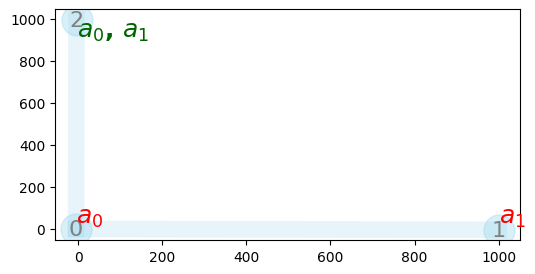

In [2]:
importlib.reload(flpoAgent)
importlib.reload(createEnv)
importlib.reload(supporting_functions)

# generate waypoints and the adjacency matrix
n_waypoints = 3
n_agents = 2
tolArray = np.random.uniform(3.0, 3.0, n_waypoints)

# Grid network parameters
grid_params = {
    'type':'grid',
    'n_points':n_waypoints,
    'grid_size':1000,
    'noise_factor':5
}

# Ring network parameters
ring_params = {
    'type':'ring',
    'num_rings':3,
    'points_per_ring':int(n_waypoints/3),
    'center_distance':1000,
    'deformation_level':50.0,
    'extra_connections':0.00,
    'missing_connections':0.05
}

# create a mars environment
mars = createEnv.MARS(
    n_waypoints, 
    n_agents, 
    tolArray, 
    grid_params, 
    seed=9, 
    offset_energy=1,
    selfHop=0,
    printFlag=False)

# compute conflict cost
beta0=1e-8
gamma_t = 5
gamma_c = 7.5
coeff_t = 50
coeff_c = 5.0

# mars visualization
cmap = get_cmap('tab20')
agent_colors = {a: cmap(i / mars.n_agents) for i, a in enumerate(range(mars.n_agents))}
createEnv.plotNetwork(mars=mars, figuresize=(6,3), routes=[], agent_colors=agent_colors, showEdgeLength=False)

# agent visualization
# show_graph=0
# if show_graph:
#     for i,v in enumerate(mars.agents):
#         v.showGraph(mars.wp_locations, mars.dist_mat, mars.mask, mars.sched_mat[i,:], figuresize=(10,5), showEdgeTimeLim=True)



### Write a code to solve MARS using CBF-CLF based appraoch

In [3]:
beta_min = 1e3
beta_max = 1e3
beta_grow = 1.5
beta = beta_min
beta_arr = []
while beta <= beta_max:
    beta_arr.append(beta)
    beta = beta * beta_grow

T0 = np.ones((mars.n_agents, mars.n_waypoints))
for i in range(mars.n_agents):
    if i > 0:
        T0[i] = T0[i-1] + mars.tolArray + np.random.uniform(0,5, mars.tolArray.shape)
V0 = mars.speed_vec

optimizer = {
    'name':'cbf_clf',
    'dt_init':0.01,
    'dt_min':1e-4,
    'dt_max':0.1,
    'Tf':20,
    'gamma':1,
    'alpha':10,
    'p':1,
    'stop_tol':0.0001,
    'stop_tol_weight':np.array([1, 1, 1]),
    'verbose':2
}



In [4]:

active_waypoints = [] #range(mars.n_waypoints) 
T, V, F, Pb_a = mars.anneal(
    beta_arr, 
    T0, 
    V0, 
    active_waypoints=active_waypoints, 
    optimizer=optimizer, 
    annealPrint=True)



hereeeeeeeehjejdhjfhdjhf
speed_vec:[35.96096321 36.16403899]
speed_lim:[[ 0.50081556 71.42111085]
 [ 0.14249123 72.18558676]]
H_speed:[1257.42207116 1297.55190312]
H_grad:[[0. 0.]
 [0. 0.]]
U2:[ 7.95648599 15.73784042]
H_speed_dot:[0. 0.]
H_constraint: [12574.22071159 12975.51903119]

	t:0.000e+00	Fdot:-2315.0216	F:2315.2077	dt:1.0000e-02	speed: [35.96096321 36.16403899]	delta:0.1861	tol:7.791e+02
hereeeeeeeehjejdhjfhdjhf
speed_vec:[36.04052807 36.3214174 ]
speed_lim:[[ 0.50081556 71.42111085]
 [ 0.14249123 72.18558676]]
H_speed:[1257.41574059 1297.52713516]
H_grad:[[-0.15912972  0.        ]
 [ 0.         -0.31475681]]
U2:[ 7.98779945 15.71258328]
H_speed_dot:[-1.27109629 -4.94564256]
H_constraint: [12572.88630963 12970.32570901]

	t:1.000e-02	Fdot:-2291.9987	F:2292.1871	dt:1.0000e-01	speed: [36.04052807 36.3214174 ]	delta:0.1884	tol:8.427e+01
hereeeeeeeehjejdhjfhdjhf
speed_vec:[36.83930801 37.89267573]
speed_lim:[[ 0.50081556 71.42111085]
 [ 0.14249123 72.18558676]]
H_speed:[1256.6505

TypeError: unsupported operand type(s) for +: 'NoneType' and 'float'

In [22]:
mars.sched_mat = T
agent_routes, agent_schedules = createEnv.calc_agent_routes_and_schedules(mars, Pb_a, printRoutes=True)
createEnv.plotNetwork(mars=mars, figuresize=(6,3), routes=agent_routes, agent_colors=agent_colors, showEdgeLength=False)


route v0: [2, 0], schedule: [1.000e-02 1.353e+01]


IndexError: index 1 is out of bounds for axis 0 with size 1

In [6]:
(71.42-61.25)*(61.25-0.5), (72.18-73.75)*(73.75-0.142)

(617.8275000000001, -115.5645599999995)

In [3]:
# agent_0 = mars.agents[0]
# sched0_init = mars.sched_mat[0,:]
# lb0 = np.zeros(sched0_init.shape)
# ub0 = 100 * np.ones(lb0.shape)
# bounds = Bounds(lb0, ub0)
# speed = 50

In [4]:
# beta_min = 1e-5
# beta_max = 1e3
# beta_grow = 3
# beta = beta_min
# beta_arr = []
# while beta <= beta_max:
#     beta_arr.append(beta)
#     beta = beta * beta_grow

In [5]:
# for i, b in enumerate(beta_arr):
#     res = minimize(
#         agent_0.getFreeEnergy_s_v1,
#         sched0_init,
#         args = (mars.dist_mat, b),
#         method='slsqp',
#         options={'disp':0},
#         bounds=bounds
#     )
#     sched0_init = res.x

#     print(f'beta:{b:.4e}\tfreeEnergy:{res.fun:.4f}')



### Test the optimization for all the agents together

In [7]:
# # annealing
# sched_vec0 = mars.sched_mat.flatten()

# lb = np.ones(shape=sched_vec0.shape)*mars.t_start_min
# ub = np.ones(shape=sched_vec0.shape)*100.0
# print(f'agent start nodes {mars.agents[0].s}')
# print(f'init schedule vec {sched_vec0}')
# print(f'ub {ub}')
# print(f'lb {lb}')

# sched_bounds = [lb,ub]
# beta_lims = [1e-6,1]
# beta_grow = 1.5
# # opts = {'gtol':1e-4, 'verbose':0, 'maxiter':200}
# opts = {'disp':0}
# C_arr, sched_vec, rt_arr, reach_mat_beta_data, filter_wp_beta_data, beta_arr, gamma_arr, conflict_C_arr, Pb_a = mars.annealing_v1(beta_lims=beta_lims,
#                                             beta_grow=beta_grow,
#                                             sched_vec0=sched_vec0,
#                                             init_sched_bounds=sched_bounds,
#                                             optimize_opt=opts,
#                                             allowPrintAnneal=True,
#                                             allowPrintOptimize=False)

# # C_arr, sched_vec, rt_arr, reach_mat_beta_data, filter_wp_beta_data, beta_arr, gamma_arr, conflict_C_arr, Pb_a = mars.annealing(beta_lims=beta_lims,
# #                                             beta_grow=beta_grow,
# #                                             sched_vec0=sched_vec0,
# #                                             init_sched_bounds=sched_bounds,
# #                                             optimize_opt=opts,
# #                                             allowPrintAnneal=True,
# #                                             allowPrintOptimize=False)



In [8]:
# importlib.reload(createEnv)
# importlib.reload(flpoAgent)
# print('\nOptimization Results')
# print(f'initial schedule:{sched_vec0}')
# print(f'final schedule:\n{mars.sched_mat}')
# print(f'processing time:\n{mars.process_T}')
# print(f'cost:{C_arr[-1]}')

# agent_routes, agent_schedules = createEnv.calc_agent_routes_and_schedules(mars, Pb_a, printRoutes=True)
# createEnv.plotNetwork(mars=mars, figuresize=(12,8), routes=agent_routes, agent_colors=agent_colors, showEdgeLength=False, plotPaths=True)
# # createEnv.plot_vehicle_routes(agent_routes, agent_schedules, mars.process_T, agent_colors)
# # createEnv.plot_waypoint_schedules(filter_wp_beta_data[-1], mars.sched_mat)
# createEnv.plot_waypoint_agent_schedules(
#     agent_routes, agent_schedules, mars.sched_mat, 
#     filter_wp_beta_data[-1], mars.process_T, agent_colors,
#     figuresize=(12,12))
# plt.figure(figsize=(8,4))
# plt.plot(np.log(beta_arr)/np.log(10), conflict_C_arr.sum(axis=1), marker='o', linewidth=2, color='red')
# plt.xlabel(rf'$\log\beta$', fontsize=14)
# plt.ylabel(rf'Cost', fontsize=14)
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=14)
# plt.grid()
# plt.show()
# # agent visualization
# show_graph=0
# if show_graph:
#     for i,v in enumerate(mars.agents):
#         v.showGraph(mars.wp_locations, mars.dist_mat, mars.mask, mars.sched_mat[i,:], figuresize=(10,5), showEdgeTimeLim=True)



In [15]:


# reach_mat = mars.calc_agent_reach_mat_v1(mars.sched_mat, beta_arr[-1])
# filter_wp = np.ones(shape=reach_mat.shape)
# filter_wp[reach_mat <= 1.0e-10] = 0.0
# createEnv.plot_waypoint_agent_schedules(agent_routes, agent_schedules, mars.sched_mat, filter_wp, mars.process_T, agent_colors, figuresize=(16,18))



In [11]:
import cvxpy as cp
import numpy as np

def F_Fgrad1(V, t1, t2, t3, l1, l2):
    cost = (l2/V)**2 + (t3 - t2 - l2/V)**2 + (l1/V)**2 + (t2 - t1 - l1/V)**2 + t1**2
    grad = np.array([
        2*(t1 - t2 + l1/V) + 2*t1,
        2*(t2 - t1 - l1/V) + 2*(t2 - t3 + l2/V),
        2*(t3 - t2 - l2/V),
        2*l2/V**2 * (t2 - t1 - 2*l2/V) + 2*l1/V**2 * (t3 - t2 - 2*l1/V)
    ])
    return cost, grad

def H_Hgrad(V, Vmin, Vmax):
    H = (Vmax - V)*(V - Vmin)
    grad_H = Vmax + Vmin - 2*V
    return H, grad_H

In [30]:
np.random.seed(5)
M = np.diag(np.random.uniform(0,1,3))
U = np.random.uniform(0,1,3)
M, U

(array([[0.22199317, 0.        , 0.        ],
        [0.        , 0.87073231, 0.        ],
        [0.        , 0.        , 0.20671916]]),
 array([0.91861091, 0.48841119, 0.61174386]))

In [38]:
A = cp.multiply(M,U.reshape(-1,1))
B = cp.sum(A, axis=1)
A.value, B.value

(array([[0.20392535, 0.        , 0.        ],
        [0.        , 0.4252754 , 0.        ],
        [0.        , 0.        , 0.12645917]]),
 array([0.20392535, 0.4252754 , 0.12645917]))

In [13]:
U1 = cp.Variable(1)
U2 = cp.Variable(1)
U3 = cp.Variable(1)
U4 = cp.Variable(1)
U5 = cp.Variable(1)
U6 = cp.Variable(1)
U7 = cp.Variable(1)
U8 = cp.Variable(1)
delta = cp.Variable(1)

t1, t2, t3 = np.random.uniform(0,1000, 3)
t4, t5, t6 = np.random.uniform(0,1000, 3)
V1, V2 = np.random.uniform(10,20,2)
gamma = 1
alpha = 1
iters = 3000
step_size = 0.01

l1 = 1000
l2 = 1000
Vmin1, Vmax1 = 0.1, 73
Vmin2, Vmax2 = 0.1, 100

for i in range(iters):
    objective = cp.Minimize(U1**2 + U2**2 + U3**2 + U4**2 + U5**2 + U6**2 + U7**2 + U8**2 + delta**2)

    F1, Fgrad1 = F_Fgrad1(V1, t1, t2, t3, l1, l2)
    Fdot1 = cp.multiply(Fgrad1[0], U1) + cp.multiply(Fgrad1[1], U2) + cp.multiply(Fgrad1[2], U3) + cp.multiply(Fgrad1[3], U4)

    F2, Fgrad2 = F_Fgrad1(V2, t4, t5, t6, l2, l1)
    Fdot2 = cp.multiply(Fgrad2[0], U5) + cp.multiply(Fgrad2[1], U6) + cp.multiply(Fgrad2[2], U7) + cp.multiply(Fgrad2[3], U8)

    F = F1 + F2
    Fdot = Fdot1 + Fdot2

    H1, Hgrad1 = H_Hgrad(V1, Vmax1, Vmin1)
    Hdot1 = cp.multiply(Hgrad1, U4)

    H2, Hgrad2 = H_Hgrad(V2, Vmax2, Vmin2)
    Hdot2 = cp.multiply(Hgrad2, U8)

    constraints = [
        Fdot <= -gamma * F + delta,
        Hdot1 >= -alpha * H1,
        Hdot2 >= -alpha * H2,
        U1 >= -alpha * t1,
        U5 >= -alpha * t4
    ]

    problem = cp.Problem(objective, constraints)
    solver_options = {
        'max_iter': 50000,         # Increase max iterations to 20000
        'eps_abs': 1e-4,           # Adjust absolute tolerance
        'eps_rel': 1e-4,           # Adjust relative tolerance
        'eps_prim_inf': 1e-3,      # Adjust primal infeasibility tolerance
        'eps_dual_inf': 1e-3,      # Adjust dual infeasibility tolerance
        'verbose': False           # Enable verbose output to track solver progress
    }
    result = problem.solve(solver = 'OSQP', **solver_options)

    t1 = t1 + step_size * U1.value
    t2 = t2 + step_size * U2.value
    t3 = t3 + step_size * U3.value
    V1 = V1 + step_size * U4.value
    t4 = t4 + step_size * U5.value
    t5 = t5 + step_size * U6.value
    t6 = t6 + step_size * U7.value
    V2 = V2 + step_size * U8.value

    if i > 0:
        print(f'F:{F[0]:.1f}\tFdot:{Fdot.value[0]:.1f}\tt1:{t1[0]:.1f}\tt2:{t2[0]:.1f}\tt3:{t3[0]:.1f}\tV:{V1[0]:.1f}\tt4:{t4[0]:.1f}\tt5:{t5[0]:.1f}\tt6:{t6[0]:.1f}\tV2:{V2[0]:.1f}')
    # print(f'iter:{i}\tt1:{t1[0]:.3f}\tt2:{t2[0]:.3f}\tt3:{t3[0]:.3f}\tV:{V[0]:.3f}\tU1:{U1.value[0]:.3f}\tU2:{U2.value[0]:.3f}\tU3:{U3.value:.3f}')


F:875696.4	Fdot:-875696.3	t1:772.2	t2:628.9	t3:953.2	V:20.1	t4:211.3	t5:12.7	t6:262.7	V2:17.9
F:867212.1	Fdot:-867212.0	t1:770.1	t2:629.9	t3:952.5	V:20.2	t4:210.2	t5:13.7	t6:262.3	V2:19.1
F:858696.9	Fdot:-858696.8	t1:767.9	t2:631.0	t3:951.9	V:20.3	t4:209.2	t5:14.7	t6:261.8	V2:20.1
F:850212.6	Fdot:-850212.5	t1:765.6	t2:632.1	t3:951.3	V:20.4	t4:208.1	t5:15.8	t6:261.3	V2:20.9
F:841785.9	Fdot:-841785.8	t1:763.2	t2:633.2	t3:950.6	V:20.4	t4:207.0	t5:16.8	t6:260.8	V2:21.7
F:833428.6	Fdot:-833428.5	t1:760.9	t2:634.4	t3:949.9	V:20.5	t4:205.9	t5:17.9	t6:260.3	V2:22.4
F:825146.1	Fdot:-825146.0	t1:758.5	t2:635.5	t3:949.2	V:20.5	t4:204.7	t5:19.0	t6:259.8	V2:23.0
F:816940.8	Fdot:-816940.6	t1:756.1	t2:636.6	t3:948.6	V:20.6	t4:203.6	t5:20.1	t6:259.3	V2:23.6
F:808813.7	Fdot:-808813.6	t1:753.7	t2:637.7	t3:947.9	V:20.6	t4:202.5	t5:21.2	t6:258.8	V2:24.1
F:800765.4	Fdot:-800765.2	t1:751.3	t2:638.9	t3:947.2	V:20.6	t4:201.4	t5:22.3	t6:258.3	V2:24.6
F:792795.5	Fdot:-792795.4	t1:748.9	t2:640.0	t3:946.5	V:20.6	